In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.serif": ["Computer Modern"],
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 12,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,})

In [7]:
def peak_filter(xdata, ydata):
    id_max, property = find_peaks(ydata, prominence = 0.1)
    xmax = xdata[id_max]
    prom = property["prominences"]
    dx_max = np.sort(np.diff(xmax))
    xrate = dx_max[1:]/dx_max[:-1]
    igap = np.argmax(xrate)

    dx_small_max = dx_max[igap]
    dx_large_min = dx_max[igap + 1]
    dx_threshold = np.sqrt(dx_small_max*dx_large_min)

    groups = [[0]]
    for i in range(1, len(xmax)):
        separation = xmax[i] - xmax[i - 1]
        if separation < dx_threshold:
            groups[-1].append(i)
        else:
            groups.append([i])

    selected = []
    for group in groups:
        group = np.asarray(group)
        best = group[np.argmax(prom[group])]
        selected.append(best)
    selected = np.asarray(selected)

    id_clean = id_max[selected]
    x_clean = xdata[id_clean]
    y_clean = ydata[id_clean]

    x_local = np.diff(x_clean)
    x_mean = np.mean(x_local)
    x_std = np.std(x_local, ddof = 1)
    x_unc = x_std / np.sqrt(len(x_local))
    return {"x_peak":x_clean, "y_peak":y_clean, "mean_distance":(x_mean, x_unc)}

In [8]:
tVpps = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8]) # Sólo tenemos datos de Rubidio 87.
Vpps = np.array([])
voltages = list()
times = list()
for i in range(0, len(tVpps)):
    try:
        route = f"{tVpps[i]}Vpp/CH2.CSV"
        data = pd.read_csv(route)
        voltages.append(data["Voltage [V]"].to_numpy())
        times.append(data["Time [s]"].to_numpy())
        Vpps = np.append(Vpps, tVpps[i])
    except Exception as e:
        None

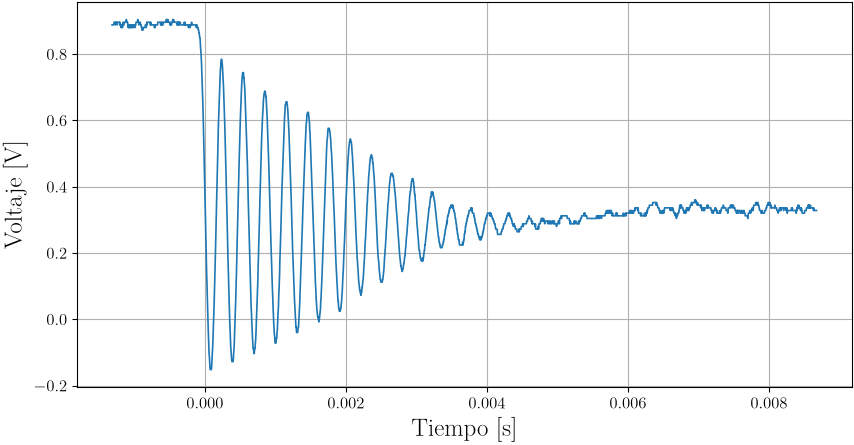

In [12]:
fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(times[6], voltages[6])
ax.set_ylabel("Voltaje [V]")
ax.set_xlabel("Tiempo [s]")
ax.grid(True)
plt.savefig("Oscillations.pdf")

(array([0.000854  , 0.00069467, 0.000519  , 0.000496  , 0.0004015 ,
        0.00044514, 0.00029636]),
 array([2.44676657e-05, 3.46666667e-05, 1.79801478e-05, 2.00798406e-05,
        6.45589432e-06, 6.37418262e-05, 3.67614602e-06]))

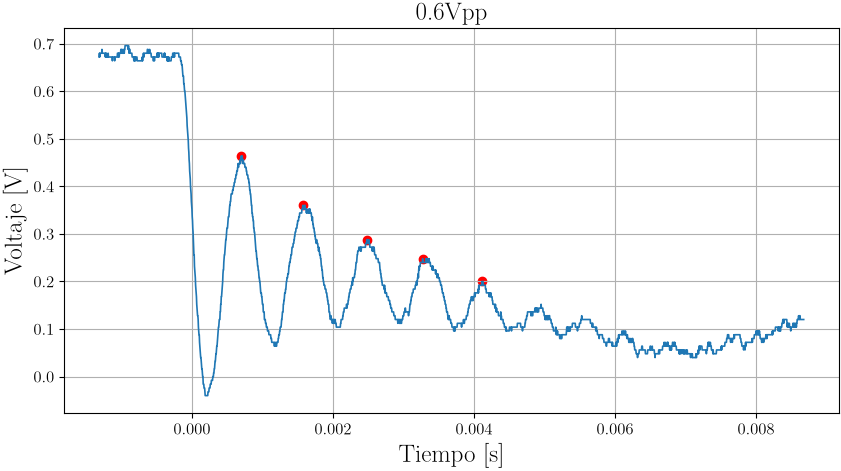

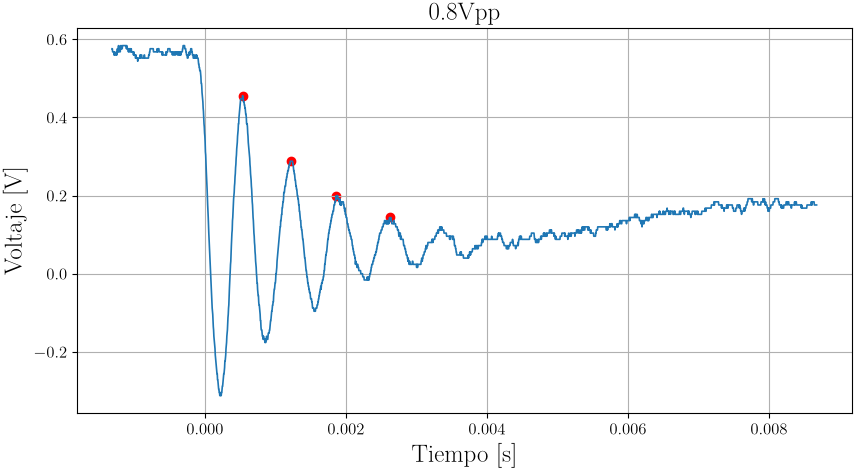

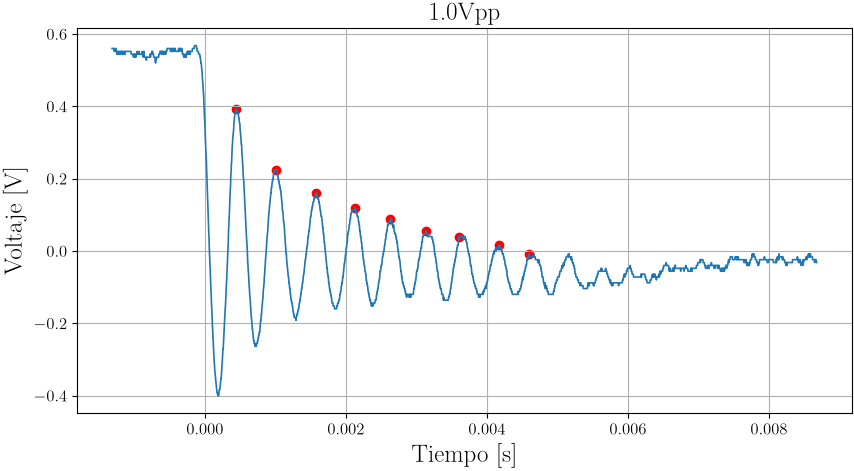

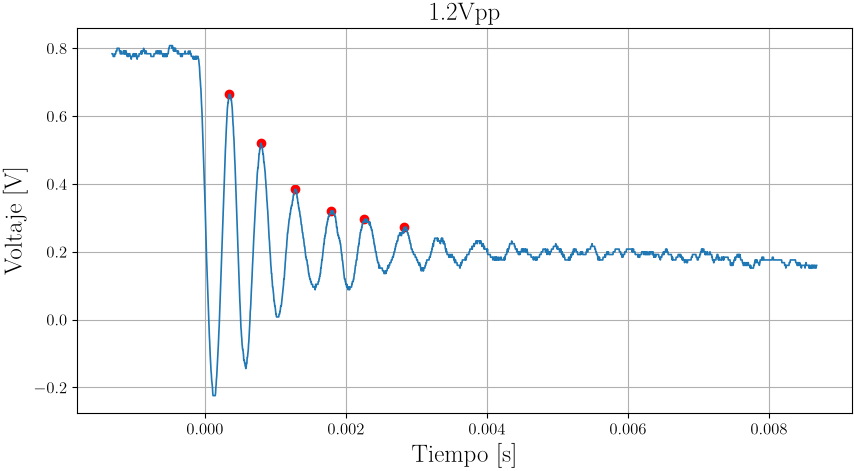

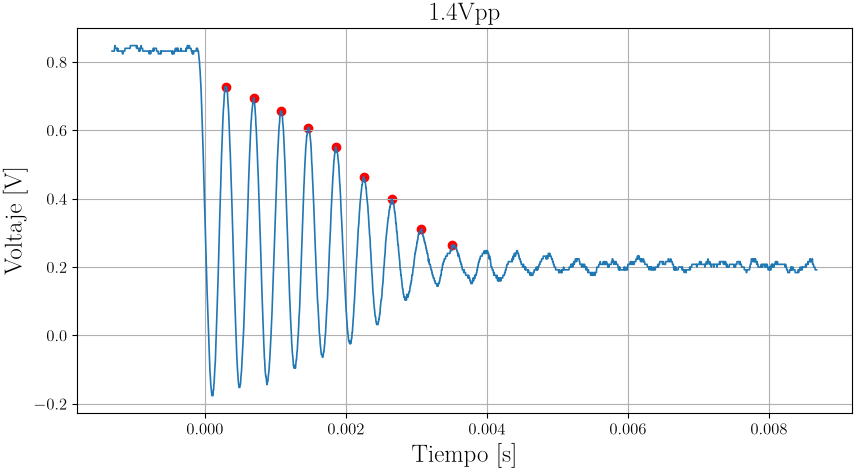

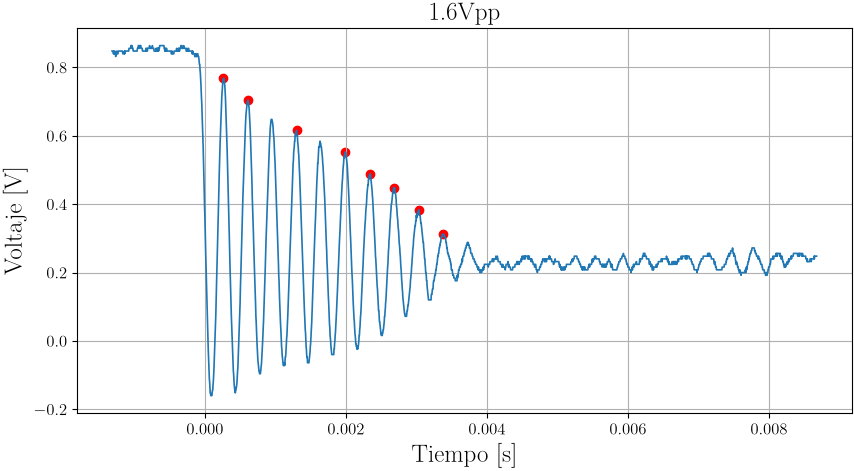

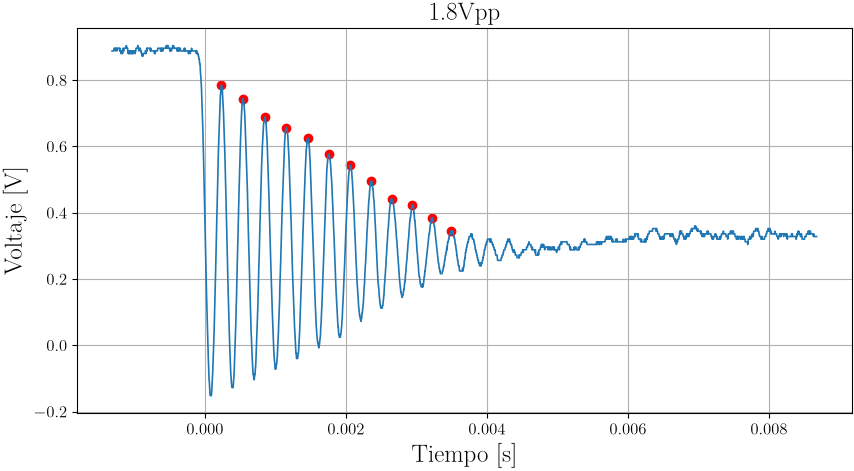

In [9]:
periods = np.array([])
unc_periods = np.array([])
index = 0
for time, voltage in zip(times, voltages):
    fig, ax = plt.subplots(figsize = (10, 5))
    ax.plot(time, voltage)
    dict = peak_filter(time, voltage)
    periods = np.append(periods, dict["mean_distance"][0])
    unc_periods = np.append(unc_periods, dict["mean_distance"][1])
    ax.scatter(dict["x_peak"], dict["y_peak"], color = "red")
    ax.set_ylabel("Voltaje [V]")
    ax.set_xlabel("Tiempo [s]")
    ax.set_title(f"{Vpps[index]}Vpp")
    ax.grid(True)
    index += 1
periods, unc_periods

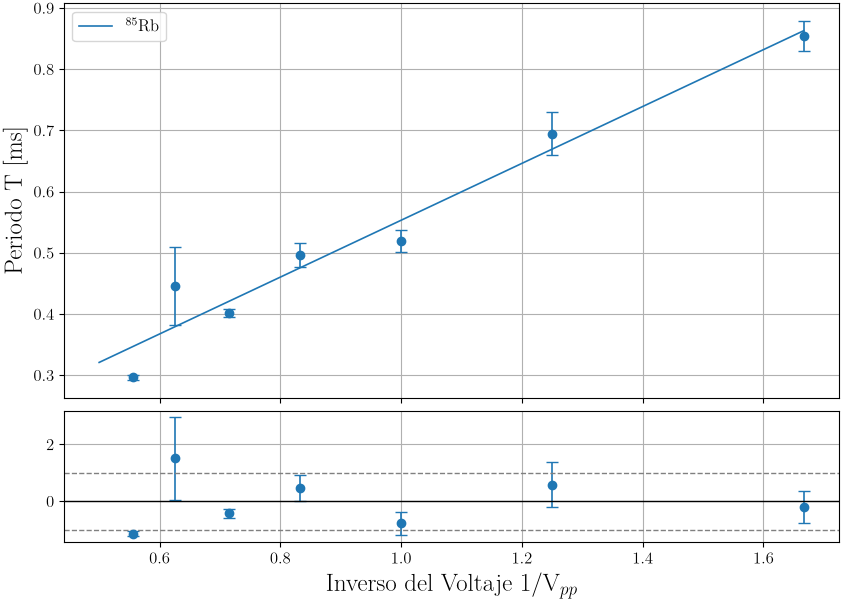

In [10]:
fig, ax = plt.subplots(2, 1, figsize = (10, 7), sharex = True, gridspec_kw = {"height_ratios":[3,1], "hspace":0.05})
slope, intercept = np.polyfit(1/Vpps, periods, 1)
invVpps = np.linspace(0.5, 1/Vpps[0], 100)
tPeriods = slope*invVpps + intercept

periods_fit = slope * 1/Vpps + intercept
residuals = periods - periods_fit
norm_residuals = residuals / np.std(residuals, ddof = 2)
norm_unc = unc_periods / np.std(residuals, ddof = 2)

ax[0].errorbar(1/Vpps, periods*1000, yerr = unc_periods*1000, fmt = "o", color = "#1f77b4", capsize = 4)
ax[0].plot(invVpps, tPeriods*1000, label = r"$^{85}$Rb")
ax[1].errorbar(1/Vpps, norm_residuals, yerr = norm_unc, fmt = "o", color = "#1f77b4", capsize = 4)
ax[1].axhline(0, color = "black", linewidth = 1)
ax[1].axhline(1, color = 'gray', linestyle='--', linewidth = 1)
ax[1].axhline(-1, color = 'gray', linestyle='--', linewidth = 1)
ax[1].set_xlabel(r"Inverso del Voltaje 1/$\mathrm{V}_{pp}$")
ax[0].set_ylabel(r"Periodo T [ms]")
ax[0].grid(True)
ax[1].grid(True)
ax[0].legend()
plt.savefig("Rabi85.pdf")